# Исследование и проверка гипотез по данным сервиса аренды самокатов

Вы аналитик популярного сервиса аренды самокатов GoFast. Вам передали данные о некоторых пользователях из нескольких городов, а также об их поездках. 

 **Цель исследования:**\
проанализировать данные и проверить некоторые гипотезы, которые могут помочь бизнесу вырасти.


 **Описание данных:**\
данные сервиса аренды самокатов GoFast:  информация о пользователях, их поездках и подписках.\
Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться:
* без подписки: абонентская плата отсутствует; стоимость одной минуты поездки — 8 рублей; стоимость старта (начала поездки) — 50 рублей;
* с подпиской Ultra: абонентская плата — 199 рублей в месяц; стоимость одной минуты поездки - 6 рублей; стоимость старта — бесплатно.

**План исследования:**
1) открыть файл с данными и изучить общую информацию;\
2) выполнить предобработку данных (проверить типы данных в столбцах, создать новый столбец, обработать пропуски и дубликаты);\
3) провести исследовательский анализ (описать и визуализировать общую информацию о пользователях и поездках);\
4) объединить данные, создать датафреймы по разным группам с типом подписки и визуализировать их;\
5) подсчитать выручку;\
6) проверить гипотезы;\
7) общий вывод.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st

### Шаг 1. Загрузка данных

#### Загрузка данных

In [2]:
# сохраняем датафрейм с информацией о пользователях
try:
    users = pd.read_csv('/datasets/users_go.csv')
except:
    users = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')

# сохраняем датафрейм с информацией о поездках
try:
    rides = pd.read_csv('/datasets/rides_go.csv')
except:
    rides = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')

# сохраняем датафрейм с информацией о подписках    
try:
    subscriptions = pd.read_csv('/datasets/subscriptions_go.csv')
except:
    subscriptions = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')


#### Общая информация

In [3]:
# смотрим основную информацию датафрейма users
display(users.head())
print()
users.info()

# сохраняем количество строк в датафрейме в переменную, 
# чтобы потом подсчитать процент удаленных данных
print()
users_len_1 = len(users)

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB



В датафрейме нет ни пропусков, ни несоответствующих типов данных.

In [4]:
# смотрим основную информацию датафрейма rides
display(rides.head())
print()
rides.info()

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


В датафрейме нет пропусков, но тип данных столбца date не соответствует правильному - datetime.

In [5]:
# смотрим основную информацию датафрейма subscriptions
display(subscriptions.head())
print()
subscriptions.info()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


В датафрейме нет ни пропусков, ни несоответствующих типов данных.

### Шаг 2. Предобработка данных

#### Тип данных

In [6]:
# меняем тип данных в столбце date на datetime
rides['date'] = pd.to_datetime(rides['date'], format='%Y-%m-%d')

# проверяем
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


#### Создание стобца с месяцем поездки

In [7]:
rides['month'] = rides['date'].dt.month
display(rides.head())

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


#### Обработка пропусков и дубликатов

##### Обработка пропусков

In [8]:
# выводим количество пропущенных значений для каждого столбца датафрейма users
print(users.isna().sum())
print()

# выводим количество пропущенных значений для каждого столбца датафрейма rides
print(rides.isna().sum())
print()

# выводим количество пропущенных значений для каждого столбца датафрейма subscriptions
print(subscriptions.isna().sum())

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64


Пропусков в датафреймах нет

##### Обработка дубликатов

In [9]:
# проверяем на наличие явных дубликатов датафрейм users
print(users.duplicated().sum())
print()

# проверяем на наличие явных дубликатов датафрейм rides
print(rides.duplicated().sum())
print()

# проверяем на наличие явных дубликатов датафрейм subscriptions
print(subscriptions.duplicated().sum())
print()


31

0

0



Обнаружены явные дубликаты в датафрейме users

In [10]:
# удаляем явные дубликаты датафрейма users
users = users.drop_duplicates().reset_index(drop=True) 

# проверяем, что удалили все явные дубликаты в датафрейме users
print(users.duplicated().sum())

0


Неявных дубликатов в датафреймах rides и subscriptions не может быть, поэтому посмотрим только датафрейм users.

In [13]:
# проверяем на наличие неявных дубликатов датафрейм users столбец city
users['city'].unique()

array(['Тюмень', 'Омск', 'Москва', 'Ростов-на-Дону', 'Краснодар',
       'Пятигорск', 'Екатеринбург', 'Сочи'], dtype=object)

In [15]:
# проверяем, что процент удаленных данных в датафрейме users не повлияет на объективность результатов
users_len_2 = len(users)
print(round(100 - ((users_len_2/users_len_1)*100), 2))

1.98


На этапе обработки от пропусков и дубликатов датафрейма users было удалено 1.98% данных.

### Шаг 3. Исследовательский анализ данных

#### Частота встречаемости городов

                count
city                 
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168



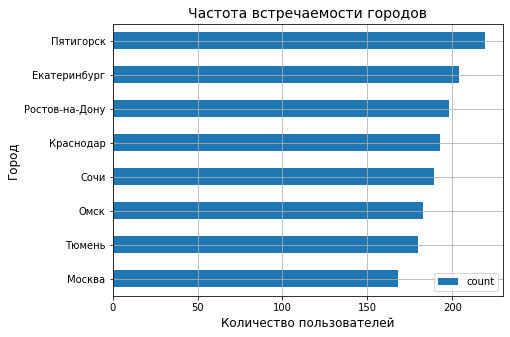

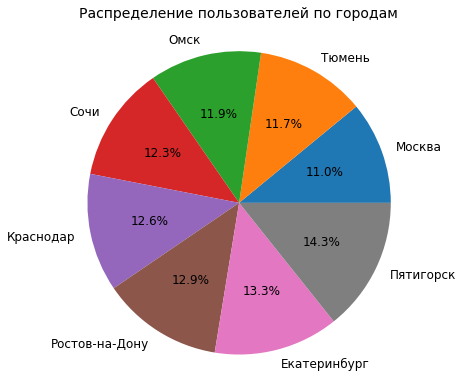

In [16]:
# делаем сводную таблицу - группируем по названию города и считаем количество
# пользователей из разных городов
cities = users.pivot_table(index='city', values='user_id', aggfunc='count')
cities.columns = ['count']
cities = cities.sort_values(by='count', ascending=False)
print(cities)
print()


# строим горизонтальную столбчатую диаграмму
cities = cities.sort_values(by='count', ascending=True)
cities.plot(kind='barh', figsize=(7,5), rot=0, grid=True)
plt.title('Частота встречаемости городов', fontsize=14)
plt.ylabel('Город', fontsize=12)
plt.xlabel('Количество пользователей', fontsize=12)
plt.show()
print()


# строим круговую диаграмму с процентами
plt.figure(figsize=(6, 6))
plt.pie(cities['count'], labels=cities.index, autopct='%1.1f%%', textprops={'fontsize': 12})
plt.title('Распределение пользователей по городам', fontsize=14, y=1.05)
plt.axis('equal') 
plt.show()

Больше всего пользователей в Пятигорске (219 человек или 14.3% от количества всех пользователей), потом в порядке убывания в следующих городах: Екатеринбург, Ростов-на-Дону, Краснодар, Сочи, Омск, Тюмень,. \
Минимальное количество пользователей в Москве (168 человек - 11%).

#### Соотношение пользователей с подпиской и без подписки

                   count
subscription_type       
free                 835
ultra                699


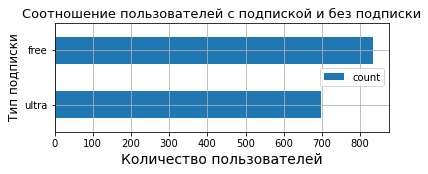

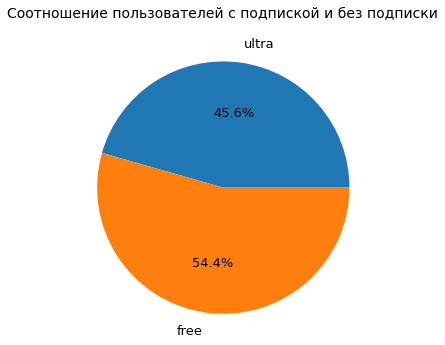

In [17]:
# делаем сводную таблицу - группируем по типу подписки и считаем количество пользователей 
subscr = users.pivot_table(index='subscription_type', values='user_id', aggfunc='count')
subscr.columns = ['count']
print(subscr)


# строим горизонтальную столбчатую диаграмму
subscr = subscr.sort_values(by='count', ascending=True)
subscr.plot(kind='barh', figsize=(6,2), grid=True)
plt.title('Соотношение пользователей с подпиской и без подписки', fontsize=13)
plt.ylabel('Тип подписки', fontsize=12)
plt.xlabel('Количество пользователей', fontsize=14)
plt.show()
print()

# строим круговую диаграмму с процентами
plt.figure(figsize=(5, 5))
plt.pie(subscr['count'], labels=subscr.index, autopct='%1.1f%%', \
        textprops={'fontsize': 13}, labeldistance=1.15)
plt.title('Соотношение пользователей с подпиской и без подписки', fontsize=14, y=1.1)
plt.axis('equal') 
plt.show()

Большую долю составляют пользователи без подписки  - 54.4% (835 человека), в то время как пользователей с подпиской 45.6% (699 человек).

#### Возраст пользователей

     count
age       
25     145
24     132
26     131
23     129
27     119

     count
age       
12       4
38       3
37       2
39       1
43       1


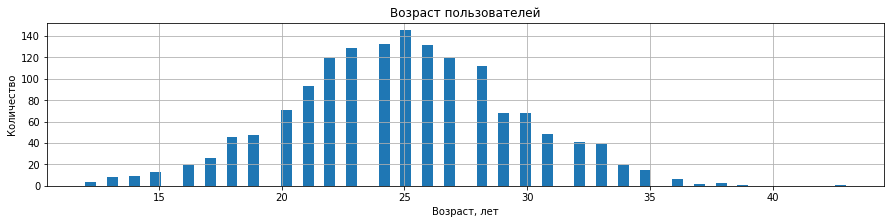

In [18]:
# делаем сводную таблицу - группируем по возрасту и считаем количество пользователей
# из датафрейма users
age = users.pivot_table(index='age', values='user_id', aggfunc='count')
age.columns = ['count']
age = age.sort_values(by='count', ascending=False)
print(age.head())
print()
print(age.tail())

# смотрим распределение по столбцу age датафрейма users
users['age'].hist(bins=70, figsize=(15,3))
plt.title('Возраст пользователей')
plt.xlabel('Возраст, лет')
plt.ylabel('Количество')
plt.show()
print()

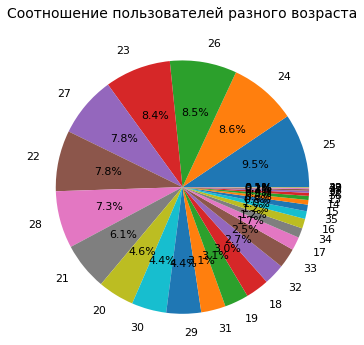

In [19]:
# строим круговую диаграмму с процентами по сводной таблице age
plt.figure(figsize=(5, 5))
plt.pie(age['count'], labels=age.index, autopct='%1.1f%%', \
        textprops={'fontsize': 11}, labeldistance=1.15)
plt.title('Соотношение пользователей разного возраста', fontsize=14, y=1.1)
plt.axis('equal') 
plt.show()

На гистограмме нормальное распределение с пиком значения возраста, равного 25 годам (145 человек или 9.5% от общего числа).\
Меньше всего пользователей 39 и 43 лет - по 1 человеку (каждый по 0.065%).

####  Расстояние, которое пользователь преодолел за одну поездку

count    1534.000000
mean     3077.296650
std       327.624403
min      1630.788427
25%      2882.505704
50%      3090.864050
75%      3293.325678
max      4287.519387
Name: distance, dtype: float64


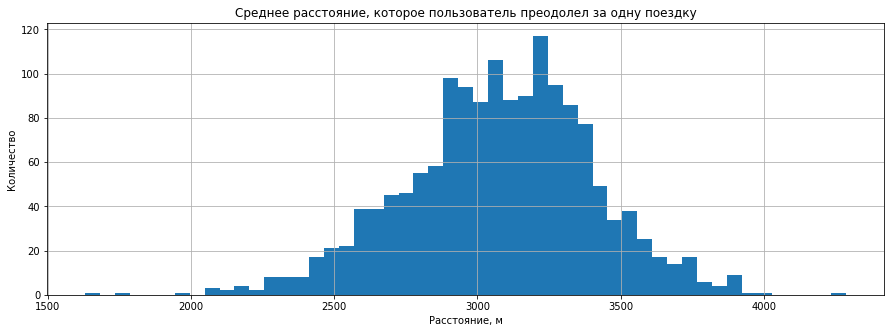

In [20]:
# делаем сводную таблицу - группируем по пользователю и считаем 
# среднюю дальность поездок у каждого
avg_ride_distance = rides.pivot_table(index='user_id', values='distance', aggfunc='mean')

# смотрим характеристики столбца distance выше созданной сводной таблицы avg_ride_distance
print(avg_ride_distance['distance'].describe())

# смотрим распределение данных с помощью гистограммы
avg_ride_distance['distance'].hist(bins=51, figsize=(15,5))
plt.title('Среднее расстояние, которое пользователь преодолел за одну поездку')
plt.xlabel('Расстояние, м')
plt.ylabel('Количество')
plt.show()
print()

Минимальное преодоленное расстояние в среднем за поездку - 1630 метров, максимальное - 4287 метров.\
Наибольшее количество пользователей обычно в среднем за одну поездку преодолевают расстояние примерно в 3200-3250 метров.

#### Продолжительность поездок

count    1534.000000
mean       17.926440
std         1.971150
min        11.163431
25%        16.613880
50%        17.903937
75%        19.198581
max        26.136000
Name: duration, dtype: float64


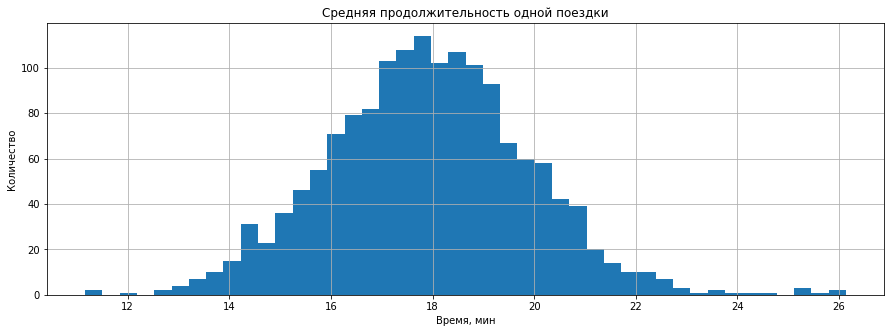

In [21]:
# делаем сводную таблицу - группируем по пользователю и считаем 
# среднюю продолжительность поездок у каждого
avg_ride_duration = rides.pivot_table(index='user_id', values='duration', aggfunc='mean')

# смотрим характеристики столбца duration выше созданной сводной таблицы avg_ride_distance
print(avg_ride_duration['duration'].describe())

# смотрим распределение данных с помощью гистограммы
avg_ride_duration['duration'].hist(bins=44, figsize=(15,5))
plt.title('Средняя продолжительность одной поездки')
plt.xlabel('Время, мин')
plt.ylabel('Количество')
plt.show()
print()

Распределение нормальное.\
Минимальное время поездки в среднем 11.1 минуты, максимальное - 26.1 минуты.\
Чаще всего пользователи тратят на поездки в среднем примерно 17.6-18 минут.

#### Вывод

Исходя из исследования на данном этапе можно сделать следующее заключение:
1) большая часть пользователей из Пятигорска (219 человек или 14.3% от количества всех пользователей), а меньше всего людей - в Москве (168 человек - 11%);\
2) пользователи без подписки составляют большую долю - 54.4% (835 человека), в то время как пользователей с подпиской - 45.6% (699 человек);\
3) наиболее часто встречаемый возраст у пользователей - 25 лет (145 человек или 9.5% от общего числа), реже всего - 39 и 43 года (по 1 человеку или по 0.065%);\
4) минимальное расстояние в среднем за поездку - 1630 метров, максимальное - 4287 метров, при этом наиболее частые поездки расстоянием примерно в 3200-3250 метров;\
5) минимальное время поездки в среднем 11.1 минуты, максимальное - 26.1 минуты, а чаще всего пользователи тратят на поездки в среднем примерно 17.6-18 минут.

### Шаг 4. Объединение данных

#### Объединение всех данных в один датафрейм

In [22]:
# объединяем данные о пользователях, поездках и подписках в один датафрейм
data = users.merge(rides, on='user_id').merge(subscriptions, on='subscription_type')
data.info()
print()
display(data.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   name               18068 non-null  object        
 2   age                18068 non-null  int64         
 3   city               18068 non-null  object        
 4   subscription_type  18068 non-null  object        
 5   distance           18068 non-null  float64       
 6   duration           18068 non-null  float64       
 7   date               18068 non-null  datetime64[ns]
 8   month              18068 non-null  int64         
 9   minute_price       18068 non-null  int64         
 10  start_ride_price   18068 non-null  int64         
 11  subscription_fee   18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.8+ MB



,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199


#### Создание двух датафреймов на основе предыдущего

In [23]:
# создаем датафрейм с данными о пользователях без подписки 
data_free = data[data['subscription_type'] == 'free']
data_free.info()
print()
display(data_free.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11568 entries, 6500 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            11568 non-null  int64         
 1   name               11568 non-null  object        
 2   age                11568 non-null  int64         
 3   city               11568 non-null  object        
 4   subscription_type  11568 non-null  object        
 5   distance           11568 non-null  float64       
 6   duration           11568 non-null  float64       
 7   date               11568 non-null  datetime64[ns]
 8   month              11568 non-null  int64         
 9   minute_price       11568 non-null  int64         
 10  start_ride_price   11568 non-null  int64         
 11  subscription_fee   11568 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.1+ MB



,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,2021-02-14,2,8,50,0


In [24]:
# создаем датафрейм с данными о пользователях с подпиской
data_ultra = data[data['subscription_type'] == 'ultra']
data_ultra.info()
print()
display(data_ultra.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6500 entries, 0 to 6499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            6500 non-null   int64         
 1   name               6500 non-null   object        
 2   age                6500 non-null   int64         
 3   city               6500 non-null   object        
 4   subscription_type  6500 non-null   object        
 5   distance           6500 non-null   float64       
 6   duration           6500 non-null   float64       
 7   date               6500 non-null   datetime64[ns]
 8   month              6500 non-null   int64         
 9   minute_price       6500 non-null   int64         
 10  start_ride_price   6500 non-null   int64         
 11  subscription_fee   6500 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 660.2+ KB



,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199


#### Визуализация расстояния и времени поездок для пользователей без и с подпиской

##### Пользователи без подписки

count     835.000000
mean     3047.023441
std       346.570021
min      1630.788427
25%      2820.516763
50%      3057.940909
75%      3276.990199
max      4287.519387
Name: distance, dtype: float64


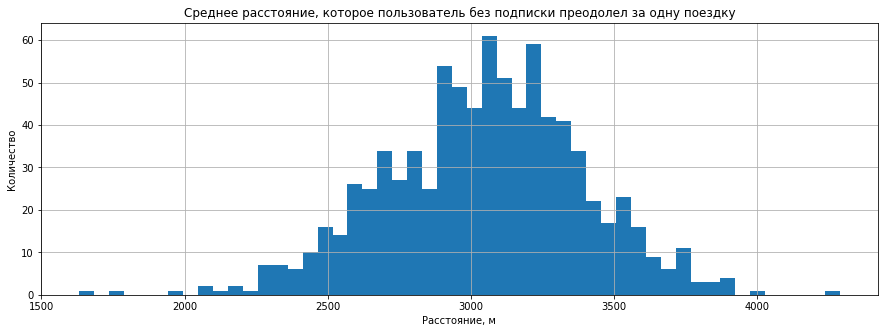

In [25]:
# Расстояние

# делаем сводную таблицу - группируем по пользователю и считаем 
# среднюю дальность поездок у каждого
avg_ride_distance_free = data_free.pivot_table(index='user_id', values='distance', aggfunc='mean')

# смотрим характеристики столбца distance выше созданной сводной таблицы
print(avg_ride_distance_free['distance'].describe())

# смотрим распределение данных с помощью гистограммы
avg_ride_distance_free['distance'].hist(bins=51, figsize=(15,5))
plt.title('Среднее расстояние, которое пользователь без подписки преодолел за одну поездку')
plt.xlabel('Расстояние, м')
plt.ylabel('Количество')
plt.show()
print()

Пользователи без подписки чаще всего преодолевают в среднем за одну поездку расстояние, равное примерно 3047 м.\
Минимальное среднее расстояние за поездку у пользователей без подписки равно 1630 метров, а максимальное - 4287 м.

count    835.000000
mean      17.384033
std        1.759845
min       11.163431
25%       16.209124
50%       17.402644
75%       18.568622
max       23.069943
Name: duration, dtype: float64


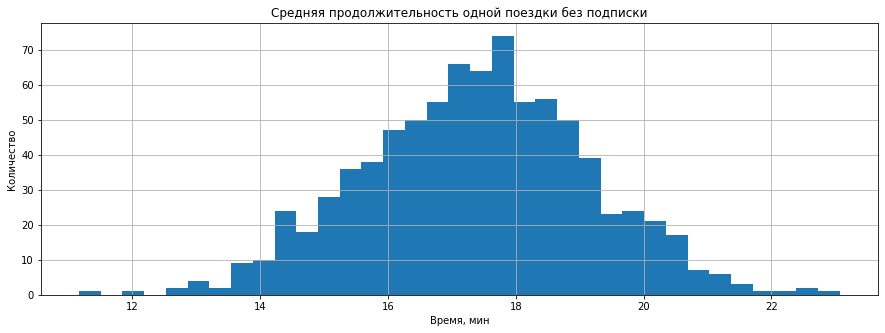

In [26]:
# Время поездок

# делаем сводную таблицу - группируем по пользователю и считаем
# среднюю длительность поездок у каждого
avg_ride_duration_free = data_free.pivot_table(index='user_id', values='duration', aggfunc='mean')

# смотрим характеристики столбца distance выше созданной сводной таблицы
print(avg_ride_duration_free['duration'].describe())

# смотрим распределение данных с помощью гистограммы
avg_ride_duration_free['duration'].hist(bins=35, figsize=(15,5))
plt.title('Средняя продолжительность одной поездки без подписки')
plt.xlabel('Время, мин')
plt.ylabel('Количество')
plt.show()
print()

Пользователи без подписки чаще всего тратят в среднем на одну поездку примерно 17.4 минуты.\
Минимальное время поездки в среднем 11.1 минуты, максимальное - 23 минуты.

##### Пользователи с подпиской

count     699.000000
mean     3113.459926
std       299.706136
min      2098.297845
25%      2925.005435
50%      3134.349186
75%      3312.191643
max      3939.773328
Name: distance, dtype: float64


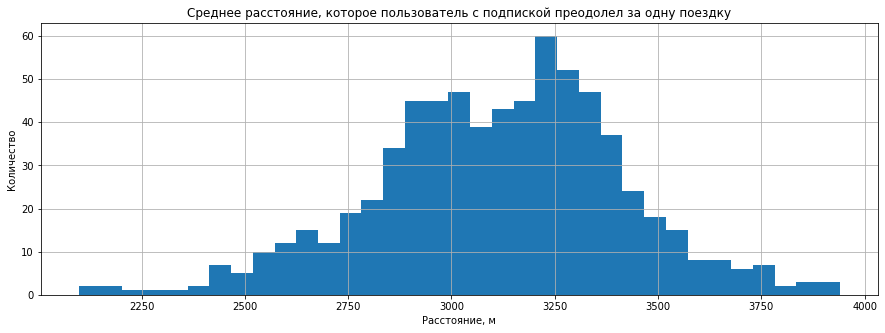

In [27]:
# делаем сводную таблицу - группируем по пользователю и считаем 
# среднюю дальность поездок у каждого
avg_ride_distance_ultra = data_ultra.pivot_table(index='user_id', values='distance', aggfunc='mean')

# смотрим характеристики столбца distance выше созданной сводной таблицы
print(avg_ride_distance_ultra['distance'].describe())

# смотрим распределение данных с помощью гистограммы
avg_ride_distance_ultra['distance'].hist(bins=35, figsize=(15,5))
plt.title('Среднее расстояние, которое пользователь с подпиской преодолел за одну поездку')
plt.xlabel('Расстояние, м')
plt.ylabel('Количество')
plt.show()
print()

Пользователи с подпиской чаще всего преодолевают в среднем за одну поездку расстояние, равное примерно 3113 м.\
Минимальное среднее расстояние за поездку у пользователей с подпиской равно 2098 метров, а максимальное - 3939 м.

count    699.000000
mean      18.574380
std        2.015094
min       11.385922
25%       17.278630
50%       18.585189
75%       19.789236
max       26.136000
Name: duration, dtype: float64


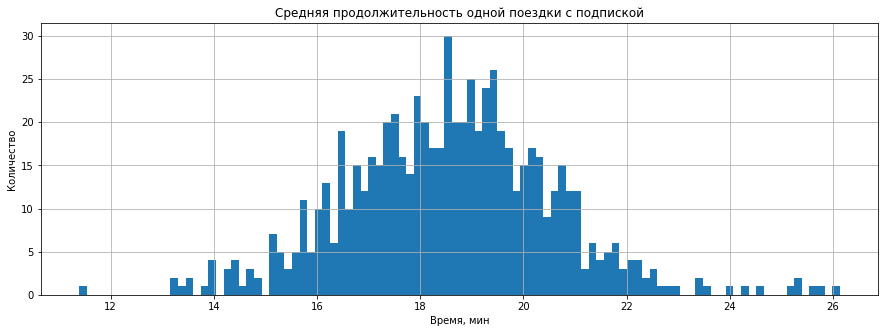

In [28]:
# Время поездок

# делаем сводную таблицу - группируем по пользователю и считаем 
# среднюю длительность поездок у каждого
avg_ride_duration_ultra = data_ultra.pivot_table(index='user_id', values='duration', aggfunc='mean')

# смотрим характеристики столбца distance выше созданной сводной таблицы
print(avg_ride_duration_ultra['duration'].describe())

# смотрим распределение данных с помощью гистограммы
avg_ride_duration_ultra['duration'].hist(bins=100, figsize=(15,5))
plt.title('Средняя продолжительность одной поездки с подпиской')
plt.xlabel('Время, мин')
plt.ylabel('Количество')
plt.show()
print()

Пользователи с подпиской чаще всего тратят в среднем на одну поездку 18.5 минут.\
Минимальное время поездки в среднем 11.3 минуты, максимальное - 26 минут.

#### Вывод

1. Пользователи с подпиской в среднем проезжают чуть большее расстояние за большее время, чем пользователи без подписки - 3113 м, 18.5 минут и 3047 м, 17.4 минуты соответственно.

\
2. Средние максимальные и минимальные показатели следующие:
* без подписки мин. расстояние равно 1630 м, а максимальное - 4287 м; мин. время равняется 11.1 минуты, максимальное - 23 минутам.
* с подпиской мин. расстояние равно 2098 м, а максимальное - 3939 м; мин. время равняется 11.3 минуты, максимальное - 26 минутам.

### Шаг 5. Подсчёт выручки

#### Создание датафрейма с агрегированными данными о поездках

In [29]:
# создаем датафрейм с агрегированными данными о поездках на основе датафрейма data
# с суммарным расстоянием, количеством поездок и суммарным временем
# для каждого пользователя за каждый месяц
user_rides_data = data.groupby(['user_id', 'month'])\
                      .agg(distance_sum=('distance', 'sum'),
                           rides_count=('distance', 'count'),
                           duration_sum=('duration', 'sum'))\
                      .reset_index()

display(user_rides_data.head())
print(user_rides_data.info())

,user_id,month,distance_sum,rides_count,duration_sum
0,1,1,7027.511294,2,41.416640
1,1,4,754.159807,1,6.232113
2,1,8,6723.470560,2,44.776802
3,1,10,5809.911100,2,31.578017
4,1,11,7003.499363,3,53.397424


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11331 entries, 0 to 11330
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       11331 non-null  int64  
 1   month         11331 non-null  int64  
 2   distance_sum  11331 non-null  float64
 3   rides_count   11331 non-null  int64  
 4   duration_sum  11331 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 442.7 KB
None


#### Создание столбца с помесячной выручкой

In [30]:
# округляем каждое значение столбца duration_sum
user_rides_data['duration_sum'] = np.ceil(user_rides_data['duration_sum']) 
display(user_rides_data)

,user_id,month,distance_sum,rides_count,duration_sum
0,1,1,7027.511294,2,42.0
1,1,4,754.159807,1,7.0
2,1,8,6723.470560,2,45.0
3,1,10,5809.911100,2,32.0
4,1,11,7003.499363,3,54.0
...,...,...,...,...,...
11326,1534,6,3409.468534,2,25.0
11327,1534,8,7622.453034,2,48.0
11328,1534,9,4928.173852,1,23.0
11329,1534,11,13350.015305,4,77.0


In [31]:
# смотрим, какие столбцы нам нужны дальше
display(data.head(2))

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199


In [32]:
# выбираем нужные для дальнейших расчетов столбцы из датафейма data
selected_columns = ['user_id', 'month', 'subscription_type', 'minute_price', 'start_ride_price', 'subscription_fee']

# cоздаем новый датафрейм
data_filter = data[selected_columns]
display(data_filter)

,user_id,month,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,1,ultra,6,0,199
1,1,1,ultra,6,0,199
2,1,4,ultra,6,0,199
3,1,8,ultra,6,0,199
4,1,8,ultra,6,0,199
...,...,...,...,...,...,...
18063,1534,11,free,8,50,0
18064,1534,11,free,8,50,0
18065,1534,11,free,8,50,0
18066,1534,11,free,8,50,0


In [33]:
# добавляем в датафрейм user_rides_data с агрегированными данными о поездках отобранные столбцы из датафрейма data_filter
user_rides_data = pd.merge(user_rides_data, data_filter, on=['user_id', 'month'], how='left')
display(user_rides_data)

,user_id,month,distance_sum,rides_count,duration_sum,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,1,7027.511294,2,42.0,ultra,6,0,199
1,1,1,7027.511294,2,42.0,ultra,6,0,199
2,1,4,754.159807,1,7.0,ultra,6,0,199
3,1,8,6723.470560,2,45.0,ultra,6,0,199
4,1,8,6723.470560,2,45.0,ultra,6,0,199
...,...,...,...,...,...,...,...,...,...
18063,1534,11,13350.015305,4,77.0,free,8,50,0
18064,1534,11,13350.015305,4,77.0,free,8,50,0
18065,1534,11,13350.015305,4,77.0,free,8,50,0
18066,1534,11,13350.015305,4,77.0,free,8,50,0


In [34]:
# строки задвоились, проверяем на дубликаты
print(user_rides_data.duplicated().sum())

6737


In [35]:
# удаляем дубликаты
user_rides_data = user_rides_data.drop_duplicates().reset_index(drop=True)
display(user_rides_data)

,user_id,month,distance_sum,rides_count,duration_sum,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,1,7027.511294,2,42.0,ultra,6,0,199
1,1,4,754.159807,1,7.0,ultra,6,0,199
2,1,8,6723.470560,2,45.0,ultra,6,0,199
3,1,10,5809.911100,2,32.0,ultra,6,0,199
4,1,11,7003.499363,3,54.0,ultra,6,0,199
...,...,...,...,...,...,...,...,...,...
11326,1534,6,3409.468534,2,25.0,free,8,50,0
11327,1534,8,7622.453034,2,48.0,free,8,50,0
11328,1534,9,4928.173852,1,23.0,free,8,50,0
11329,1534,11,13350.015305,4,77.0,free,8,50,0


Эти столбцы добавили временно, чтобы расчитать помесячную выручку с каждого пользователя, после чего их удалим.

In [36]:
# создаем столбец с помесячной выручкой с каждого пользователя

# Помесячная выручка считается по формуле: стоимость старта поездки ×  количество поездок 
# + стоимость одной минуты поездки × общая продолжительность всех поездок в минутах 
# + стоимость подписки.
user_rides_data['income'] = user_rides_data['start_ride_price']*user_rides_data['rides_count']\
+ user_rides_data['minute_price']*user_rides_data['duration_sum'] + user_rides_data['subscription_fee']
display(user_rides_data)

,user_id,month,distance_sum,rides_count,duration_sum,subscription_type,minute_price,start_ride_price,subscription_fee,income
0,1,1,7027.511294,2,42.0,ultra,6,0,199,451.0
1,1,4,754.159807,1,7.0,ultra,6,0,199,241.0
2,1,8,6723.470560,2,45.0,ultra,6,0,199,469.0
3,1,10,5809.911100,2,32.0,ultra,6,0,199,391.0
4,1,11,7003.499363,3,54.0,ultra,6,0,199,523.0
...,...,...,...,...,...,...,...,...,...,...
11326,1534,6,3409.468534,2,25.0,free,8,50,0,300.0
11327,1534,8,7622.453034,2,48.0,free,8,50,0,484.0
11328,1534,9,4928.173852,1,23.0,free,8,50,0,234.0
11329,1534,11,13350.015305,4,77.0,free,8,50,0,816.0


In [37]:
# удалим лишние столбцы, но оставим столбец с типом подписки (далее он пригодится для проверки гипотез)
user_rides_data = user_rides_data.drop(['minute_price', 'start_ride_price', 'subscription_fee'], axis=1)
display(user_rides_data)

,user_id,month,distance_sum,rides_count,duration_sum,subscription_type,income
0,1,1,7027.511294,2,42.0,ultra,451.0
1,1,4,754.159807,1,7.0,ultra,241.0
2,1,8,6723.470560,2,45.0,ultra,469.0
3,1,10,5809.911100,2,32.0,ultra,391.0
4,1,11,7003.499363,3,54.0,ultra,523.0
...,...,...,...,...,...,...,...
11326,1534,6,3409.468534,2,25.0,free,300.0
11327,1534,8,7622.453034,2,48.0,free,484.0
11328,1534,9,4928.173852,1,23.0,free,234.0
11329,1534,11,13350.015305,4,77.0,free,816.0


In [38]:
# смотрим характеристики столбца income
print(user_rides_data['income'].describe())
print()
print(user_rides_data['income'].sum())

count    11331.000000
mean       340.100344
std        151.127485
min         58.000000
25%        234.000000
50%        319.000000
75%        412.000000
max       1428.000000
Name: income, dtype: float64

3853677.0


Минимальный месячный платеж равнялся 58 рублям, максимальный - 1428 рублям.\
В среднем месячный платеж одного пользователя составил 319 рублей.\
Таким образом все пользователи принесли сервису 3 853 677 рублей за исследуемый период.

In [39]:
# отсоритруем данные из датафрейма user_rides_data в два новых:
# с пользователями без подписки и пользователями с подпиской
data_free_income = user_rides_data.loc[user_rides_data['subscription_type'] == 'free']
data_ultra_income = user_rides_data.loc[user_rides_data['subscription_type'] == 'ultra']

print(data_free_income['income'].describe())
print(data_free_income['income'].sum())
print()
print(data_ultra_income['income'].describe())
print(data_ultra_income['income'].sum())

count    6798.000000
mean      325.842895
std       180.515646
min        58.000000
25%       194.000000
50%       268.000000
75%       420.000000
max      1428.000000
Name: income, dtype: float64
2215080.0

count    4533.000000
mean      361.481800
std        86.399966
min       223.000000
25%       301.000000
50%       331.000000
75%       403.000000
max       943.000000
Name: income, dtype: float64
1638597.0


Пользователи без подписки минимально принесли за один месяц 58 рублей, максимально - 1428 рублей, а в среднем в месяц помесячная выручка составляла 268 рублей.\
Таким образом пользователи без подписки принесли сервису 2 215 080 рублей за исследуемый период.\
\
Пользователи с подпиской минимально принесли за один месяц 223 рубля, максимально - 943 рубля, а в среднем в месяц помесячная выручка составляла 331 рубль.\
Таким образом пользователи с подпиской принесли сервису 1 638 597 рублей за исследуемый период.


#### Вывод

По всем пользователям:
* Минимальный месячный платеж равнялся 58 рублям, максимальный - 1428 рублям.
* В среднем месячный платеж одного пользователя составил 319 рублей.
* Доход составил 3 853 677 рублей за исследуемый период.

\
По пользователям без подписки:
* Минимальный месячный платеж равнялся 58 рублям, максимальный - 1428 рублям.
* В среднем месячный платеж составил 268 рублей.
* Доход составил 2 215 080 рублей за исследуемый период.

\
По пользователям с подпиской:
* Минимальный месячный платеж равнялся 223 рублям, максимальный - 943 рублям.
* В среднем месячный платеж составил 331 рублей.
* Доход составил 1 638 597 рублей за исследуемый период.

### Шаг 6. Проверка гипотез

#### Тратят ли пользователи с подпиской больше времени на поездки?

In [40]:
# Нулевая гипотеза - среднее время поездок пользователей
# с подпиской и без подписки одинаково.
# Альтернативная - среднее время поездок пользователей c 
# подпиской больше, чем у пользователей без подписки.

# выводим средние показатели
print(f'среднее время поездки у пользователей без подписки:',\
      round(data_free['duration'].mean(), 1))
print(f'среднее время поездки у пользователей с подпиской:',\
      round(data_ultra['duration'].mean(), 1))
print()

# выбираем уровень статистической значимости
alpha = 0.05

# проводим двухвыборочный t-тест для двух независимых выборок
results = st.ttest_ind(data_ultra['duration'],data_free['duration'],\
                       alternative='greater', equal_var=False)

print('p-значение:', results.pvalue)
print()

if results.pvalue < alpha:
    print('Нулевая гипотеза отвергается: среднее время поездок пользователей с подпиской больше, чем у пользователей без подписки.')
else:
    print('Не получилось отвергнуть нулевую гипотезу: среднее время поездок пользователей с подпиской и без подписки одинаково.')

среднее время поездки у пользователей без подписки: 17.4
среднее время поездки у пользователей с подпиской: 18.5

p-значение: 5.6757813771289775e-37

Нулевая гипотеза отвергается: среднее время поездок пользователей с подпиской больше, чем у пользователей без подписки.



Тест показал, что есть статистическая значимость в значениях среднего времени поездки у пользователей с подпиской и без нее.\
То есть пользователи с подпиской тратят больше времени на поездки, чем пользователи без подписки.\
Следовательно, можно утверждать, что пользователи с подпиской выгоднее для компании.

####  Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? 

In [41]:
# Нулевая гипотеза - среднее расстояние, которое проезжают пользователи
# с подпиской за одну поездку, не превышает 3130 метров.
# Альтернативная - среднее расстояние, которое проезжают пользователи 
# с подпиской за одну поездку, превышает 3130 метров.

# выводим средний показатель
print(f'среднее расстояние, которое проезжают пользователи с подпиской за одну поездку:',\
      round(data_ultra['distance'].mean(), 1))

value = 3130

# выбираем уровень статистической значимости
alpha = 0.05

# проводим одновыборочный t-тест
results = st.ttest_1samp(data_ultra['distance'], value, alternative='greater')

print('p-значение:', results.pvalue)
print()

if results.pvalue < alpha:
    print('Нулевая гипотеза отвергается: среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, превышает 3130 метров')
else:
    print('Не получилось отвергнуть нулевую гипотезу: среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров.')

среднее расстояние, которое проезжают пользователи с подпиской за одну поездку: 3115.4
p-значение: 0.9195368847849785

Не получилось отвергнуть нулевую гипотезу: среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров.


Тест показал, что нет статистической значимости в значениях среднего расстояния, которое проезжают пользователи с подпиской за одну поездку и оптимальным с точки зрения износа самоката расстоянием за одну поездку в 3130 метров.\
Следовательно, среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, его не превышает.

#### Будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки?

In [42]:
# Нулевая гипотеза - помесячные выручки от пользователей с подпиской
# и без подписки равны.
# Альтернативная - помесячная выручка от пользователей с подпиской
# по месяцам выше, чем выручка от пользователей без подписки. 

# выводим медианны 
print(f'средняя помесячная выручка у пользователей без подписки:',\
      round(data_free_income['income'].median(), 1))
print(f'средняя помесячная выручка у пользователей с подпиской:',\
      round(data_ultra_income['income'].median(), 1))
print()

# выбираем уровень статистической значимости
alpha = 0.05

# проводим двухвыборочный t-тест для двух независимых выборок
results = st.ttest_ind( data_ultra_income['income'], data_free_income['income'],\
                       alternative='greater')

print('p-значение:', results.pvalue)
print()

if results.pvalue < alpha:
    print('Нулевая гипотеза отвергается: помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.')
else:
    print('Не получилось отвергнуть нулевую гипотезу: помесячные выручки от пользователей с подпиской и без подписки равны.')

средняя помесячная выручка у пользователей без подписки: 268.0
средняя помесячная выручка у пользователей с подпиской: 331.0

p-значение: 2.8130926188487286e-35

Нулевая гипотеза отвергается: помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.



Тест показал, что наблюдается статистическая значимость в значениях помесячной выручки от пользователей с подпиской и без подписки.\
Следовательно, помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.

#### Какой тест нужен был бы для проверки гипотезы?

**Дана гипотеза:**\
Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?

**Ответ:**\
Двухвыборочный t-тест для зависимых выборок.

### Шаг 8. Напишите общий вывод

**Исследование проводилось на основе** данных сервиса аренды самокатов GoFast: информация о пользователях, их поездках и подписках.\
Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться:
* без подписки: абонентская плата отсутствует; стоимость одной минуты поездки — 8 рублей; стоимость старта (начала поездки) — 50 рублей;
* с подпиской Ultra: абонентская плата — 199 рублей в месяц; стоимость одной минуты поездки - 6 рублей; стоимость старта — бесплатно.


**Задача была следующая:** проанализировать данные и проверить некоторые гипотезы, которые могут помочь бизнесу вырасти.\
\
\
**На этапе предобработки было сделано:**
1) редактирование типов данных;\
2) создание дополнительного столбца с номером месяца;\
3) обработка пропусков и дубликатов.
\
\
\
**На этапе исследовательского анализа данных было выявлено следующее:**
1) большая часть пользователей сервиса из Пятигорска (219 человек или 14.3% от количества всех пользователей), а меньше всего людей - в Москве (168 человек - 11%);\
2) пользователи без подписки составляют большую долю - 54.4% (835 человека), в то время как пользователей с подпиской - 45.6% (699 человек);\
3) наиболее часто встречаемый возраст у пользователей - 25 лет (145 человек или 9.5% от общего числа), реже всего - 39 и 43 года (по 1 человеку или по 0.065%);\
4) минимальное расстояние в среднем за поездку - 1630 метров, максимальное - 4287 метров, при этом наиболее частые поездки расстоянием примерно в 3200-3250 метров;\
5) минимальное время поездки в среднем 11.1 минуты, максимальное - 26.1 минуты, а чаще всего пользователи тратят на поездки в среднем примерно 17.6-18 минут.
\
\
\
**На этапе объединения и анализа данных было выявлено следующее:**
1) пользователи с подпиской в среднем проезжают чуть большее расстояние за большее время, чем пользователи без подписки - 3113 м, 18.5 минут и 3047 м, 17.4 минуты соответственно.\
\
2) средние максимальные и минимальные показатели:
* без подписки минимальное расстояние равно 1630 м, а максимальное - 4287 м; мин. время равняется 11.1 минуты, максимальное - 23 минутам.
* с подпиской минимальное расстояние равно 2098 м, а максимальное - 3939 м; мин. время равняется 11.3 минуты, максимальное - 26 минутам.<br>
<br>
<br>

**На этапе подсчета выручки было выявлено следующее:**

По всем пользователям:
* Минимальный месячный платеж равнялся 58 рублям, максимальный - 1428 рублям.
* В среднем месячный платеж одного пользователя составил 319 рублей.
* Доход составил 3 853 677 рублей за исследуемый период.

\
По пользователям без подписки:
* Минимальный месячный платеж равнялся 58 рублям, максимальный - 1428 рублям.
* В среднем месячный платеж составил 268 рублей.
* Доход составил 2 215 080 рублей за исследуемый период.

\
По пользователям с подпиской:
* Минимальный месячный платеж равнялся 223 рублям, максимальный - 943 рублям.
* В среднем месячный платеж составил 331 рублей.
* Доход составил 1 638 597 рублей за исследуемый период.<br>
<br>

**Заключение после проверки гипотез:**
1. Пользователи с подпиской тратят больше времени на поездки, чем пользователи без подписки.
2. Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает оптимальное с точки зрения износа самоката расстояние, равное 3130 метров.
3. Помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.
4. Необходимый для проверки гипотезы тест - двухвыборочный t-тест для зависимых выборок.
